# Notebook 5: End-to-End Pipeline Test (Local)

**Goal:** Chain all 3 models together and test:

```
image → detection → for each box:
                     ├─ severity classification
                     └─ cost prediction
```

**Also:** Save the reusable `DamagePipeline` class to `app/pipeline.py` so the Streamlit app can import it.


## 1. Load all 3 models

In [1]:
import os, json, torch, joblib
from ultralytics import YOLO
from torchvision import models, transforms
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Detection
det_model = YOLO('models/detection_best.pt')

# Severity
sev_ckpt = torch.load('models/severity_best.pt', map_location=device)
sev_model = models.resnet18(weights=None)
sev_model.fc = nn.Linear(sev_model.fc.in_features, 3)
sev_model.load_state_dict(sev_ckpt['state_dict'])
sev_model = sev_model.to(device).eval()
SEV_CLASSES = sev_ckpt['classes']

# Cost
cost_bundle = joblib.load('models/cost_model.pkl')
cost_model = cost_bundle['model']
FEATURE_COLS = cost_bundle['feature_cols']

print("Detection classes:", det_model.names)
print("Severity classes: ", SEV_CLASSES)

Device: cuda
Detection classes: {0: 'Front-windscreen-damage', 1: 'Headlight-damage', 2: 'Rear-windscreen-Damage', 3: 'Runningboard-Damage', 4: 'Sidemirror-Damage', 5: 'Taillight-Damage', 6: 'bonnet-dent', 7: 'boot-dent', 8: 'doorouter-dent', 9: 'fender-dent', 10: 'front-bumper-dent', 11: 'quaterpanel-dent', 12: 'rear-bumper-dent', 13: 'roof-dent'}
Severity classes:  ['minor', 'moderate', 'severe']


## 2. Pipeline function

In [2]:
import cv2
import numpy as np
import pandas as pd
from PIL import Image

sev_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def classify_severity(crop_bgr):
    rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    x = sev_tf(Image.fromarray(rgb)).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(sev_model(x), dim=1)[0].cpu().numpy()
    idx = int(np.argmax(probs))
    return SEV_CLASSES[idx], float(probs[idx])

def estimate_cost(damage_type, severity, area_pct):
    row = {c: 0 for c in FEATURE_COLS}
    row['area_pct'] = area_pct
    for key in (f'damage_type_{damage_type}', f'severity_{severity}'):
        if key in row: row[key] = 1
    x = pd.DataFrame([row])[FEATURE_COLS]
    return float(cost_model.predict(x)[0])

def analyze_image(image_path, conf_threshold=0.25):
    img = cv2.imread(image_path)
    if img is None: return None, []
    H, W = img.shape[:2]
    img_area = H * W

    r = det_model.predict(img, conf=conf_threshold, verbose=False)[0]

    findings = []
    annotated = img.copy()
    for box, cls, conf in zip(r.boxes.xyxy.cpu().numpy(),
                              r.boxes.cls.cpu().numpy(),
                              r.boxes.conf.cpu().numpy()):
        x1, y1, x2, y2 = map(int, box)
        damage_type = det_model.names[int(cls)]
        crop = img[max(0,y1):min(H,y2), max(0,x1):min(W,x2)]
        if crop.size == 0: continue

        severity, sev_conf = classify_severity(crop)
        area_pct = ((x2-x1) * (y2-y1)) / img_area
        cost = estimate_cost(damage_type, severity, area_pct)

        findings.append({
            'damage_type': damage_type,
            'severity': severity,
            'severity_conf': sev_conf,
            'detection_conf': float(conf),
            'area_pct': area_pct,
            'estimated_cost': cost,
            'bbox': (x1, y1, x2, y2),
        })

        color = {'minor': (0,200,0), 'moderate': (0,165,255), 'severe': (0,0,255)}[severity]
        cv2.rectangle(annotated, (x1,y1), (x2,y2), color, 2)
        label = f"{damage_type} [{severity}] INR {cost:,.0f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
        cv2.putText(annotated, label, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    return annotated, findings

print("Pipeline ready.")

Pipeline ready.


## 3. Test on validation images

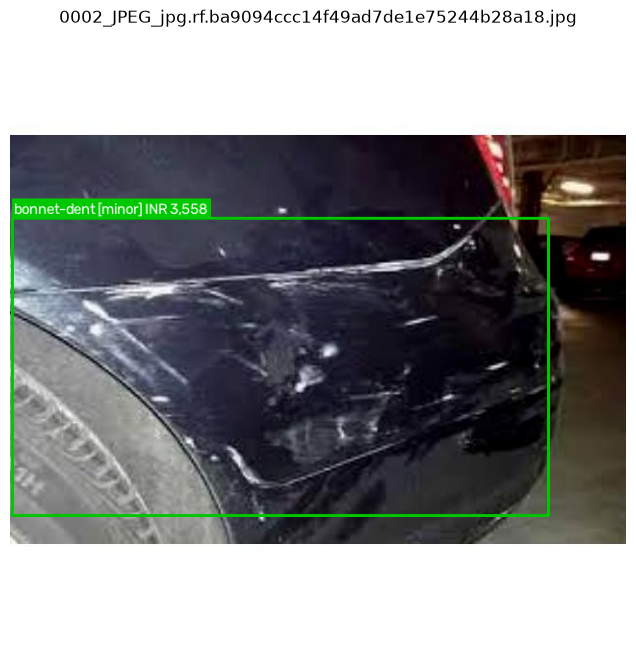

Findings: 1
  * bonnet-dent                minor    area=42.0%  INR 3,558
  TOTAL: INR 3,558



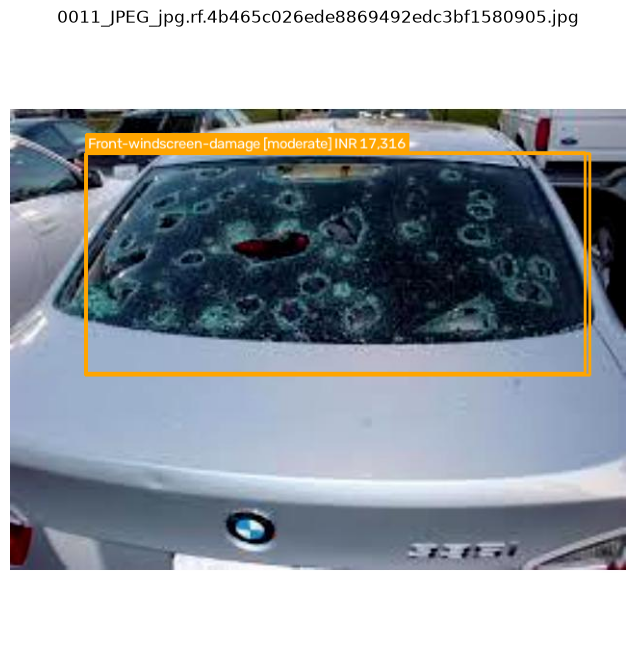

Findings: 2
  * Rear-windscreen-Damage     moderate area=29.4%  INR 16,223
  * Front-windscreen-damage    moderate area=29.0%  INR 17,316
  TOTAL: INR 33,539



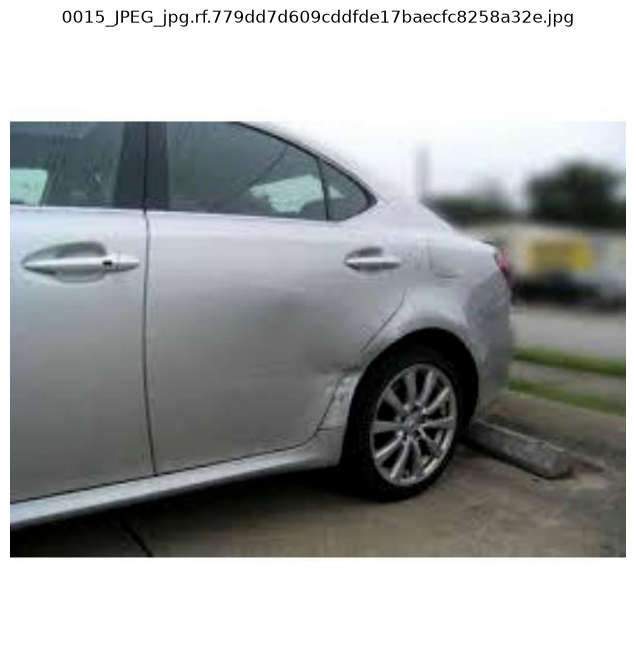

No damage detected.



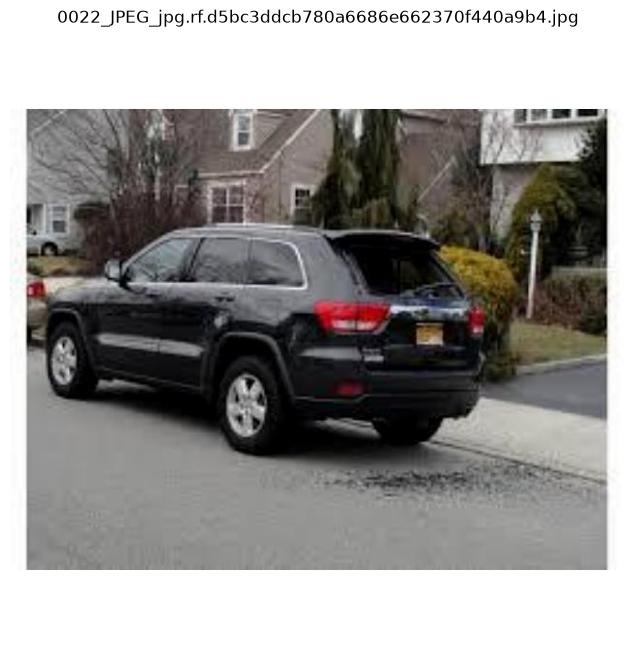

No damage detected.



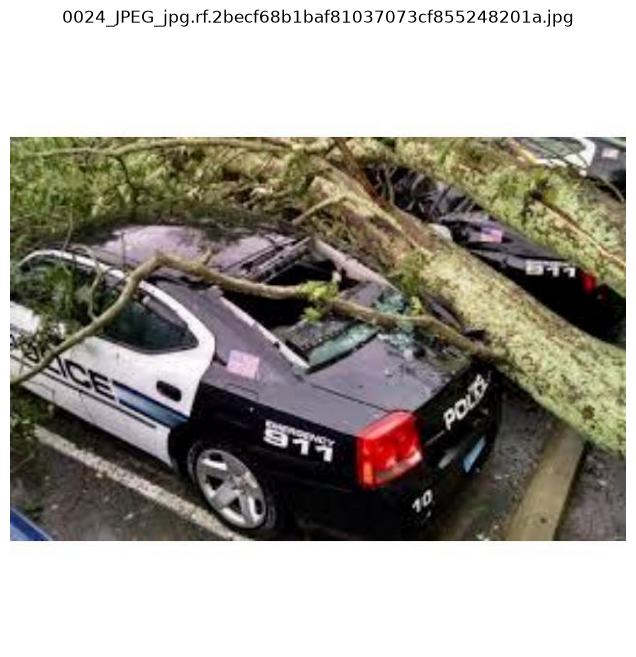

No damage detected.



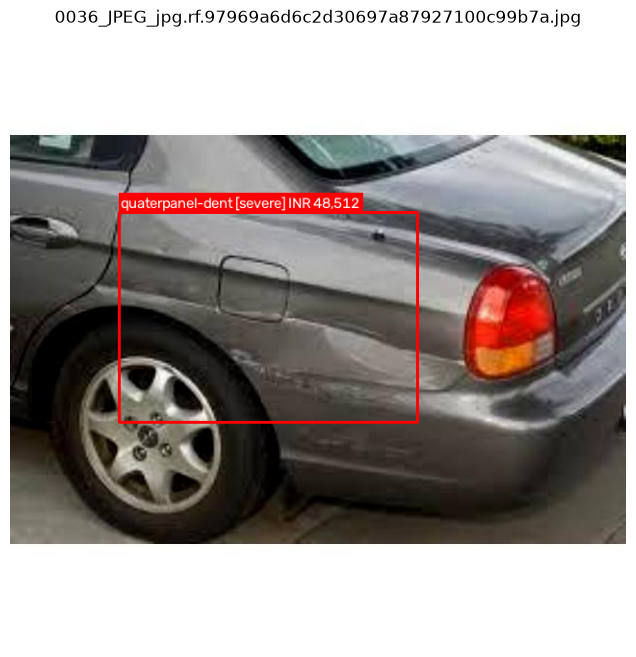

Findings: 1
  * quaterpanel-dent           severe   area=16.5%  INR 48,512
  TOTAL: INR 48,512



In [3]:
import glob
import matplotlib.pyplot as plt

with open('dataset_paths.json') as f:
    paths = json.load(f)

test_imgs = sorted(glob.glob(f"{paths['detection_dir']}/valid/images/*.jpg"))[:6]

for img_path in test_imgs:
    annotated, findings = analyze_image(img_path)
    if annotated is None: continue

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(os.path.basename(img_path))
    plt.show()

    if findings:
        total = sum(f['estimated_cost'] for f in findings)
        print(f"Findings: {len(findings)}")
        for f in findings:
            print(f"  * {f['damage_type']:26s} {f['severity']:8s} "
                  f"area={f['area_pct']*100:.1f}%  INR {f['estimated_cost']:,.0f}")
        print(f"  TOTAL: INR {total:,.0f}\n")
    else:
        print("No damage detected.\n")

## 4. Save the reusable pipeline as app/pipeline.py

In [4]:
os.makedirs('app', exist_ok=True)

pipeline_code = """\"\"\"Reusable inference pipeline for the Vehicle Damage AI project.\"\"\"
import cv2
import numpy as np
import pandas as pd
import torch
import joblib
from PIL import Image
from ultralytics import YOLO
from torchvision import models, transforms
import torch.nn as nn


class DamagePipeline:
    def __init__(self, det_path, sev_path, cost_path, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.det_model = YOLO(det_path)

        sev_ckpt = torch.load(sev_path, map_location=self.device)
        m = models.resnet18(weights=None)
        m.fc = nn.Linear(m.fc.in_features, 3)
        m.load_state_dict(sev_ckpt["state_dict"])
        self.sev_model = m.to(self.device).eval()
        self.sev_classes = sev_ckpt["classes"]

        bundle = joblib.load(cost_path)
        self.cost_model = bundle["model"]
        self.feature_cols = bundle["feature_cols"]

        self.sev_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def _classify_severity(self, crop_bgr):
        rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        x = self.sev_tf(Image.fromarray(rgb)).unsqueeze(0).to(self.device)
        with torch.no_grad():
            probs = torch.softmax(self.sev_model(x), dim=1)[0].cpu().numpy()
        idx = int(np.argmax(probs))
        return self.sev_classes[idx], float(probs[idx])

    def _estimate_cost(self, damage_type, severity, area_pct):
        row = {c: 0 for c in self.feature_cols}
        row["area_pct"] = area_pct
        for key in (f"damage_type_{damage_type}", f"severity_{severity}"):
            if key in row: row[key] = 1
        x = pd.DataFrame([row])[self.feature_cols]
        return float(self.cost_model.predict(x)[0])

    def analyze(self, img_bgr, conf_threshold=0.25):
        H, W = img_bgr.shape[:2]
        img_area = H * W
        r = self.det_model.predict(img_bgr, conf=conf_threshold, verbose=False)[0]

        findings = []
        annotated = img_bgr.copy()
        for box, cls, conf in zip(r.boxes.xyxy.cpu().numpy(),
                                  r.boxes.cls.cpu().numpy(),
                                  r.boxes.conf.cpu().numpy()):
            x1, y1, x2, y2 = map(int, box)
            damage_type = self.det_model.names[int(cls)]
            crop = img_bgr[max(0, y1):min(H, y2), max(0, x1):min(W, x2)]
            if crop.size == 0: continue

            severity, sev_conf = self._classify_severity(crop)
            area_pct = ((x2-x1) * (y2-y1)) / img_area
            cost = self._estimate_cost(damage_type, severity, area_pct)

            findings.append({
                "damage_type": damage_type,
                "severity": severity,
                "severity_conf": sev_conf,
                "detection_conf": float(conf),
                "area_pct": area_pct,
                "estimated_cost": cost,
                "bbox": (x1, y1, x2, y2),
            })

            color = {"minor": (0,200,0), "moderate": (0,165,255), "severe": (0,0,255)}[severity]
            cv2.rectangle(annotated, (x1,y1), (x2,y2), color, 2)
            label = f"{damage_type} [{severity}] INR {cost:,.0f}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(annotated, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
            cv2.putText(annotated, label, (x1+2, y1-4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        total_cost = sum(f["estimated_cost"] for f in findings)
        return annotated, findings, total_cost
"""

with open('app/pipeline.py', 'w') as f:
    f.write(pipeline_code)

print("Saved: app/pipeline.py")

Saved: app/pipeline.py


## Done

- ✅ Full pipeline validated end-to-end
- ✅ `app/pipeline.py` saved

**Next:** run the Streamlit app locally:
```powershell
streamlit run app/streamlit_app.py
```
